# 03. RAG 정책 문서 — 청킹 및 임베딩

**계획**: 데이터 확인 → 전처리(청킹) → 모델링(임베딩) → 검색 품질 검증 → 학습(DB 적재)

- 공식 정책 문서 원문을 `data/rag/{canada,australia,uk}/*.txt`에 미리 수집해 두었다 (`docs/Living_Abroad_RAG_Official_Document_Links.txt`의
  "RAG 상담 구현" 태그 문서, 총 8건 — 브라우저로 직접 접속해 본문을 추출했다. 정부 사이트가 단순 HTTP 요청/자동 크롤러를
  자주 차단해 requests 기반 스크래핑이 불안정했기 때문이다).
- 임베딩 모델은 경력·직업 매칭과 동일한 `intfloat/multilingual-e5-base`를 재사용한다 (검색 전용, 생성 모델과 역할 분리).
- 생성 모델(Qwen3-8B-AWQ + vLLM)은 별도 GPU 서버가 필요해 아직 없다. 로컬 개발 중에는 동일한 OpenAI 호환 API를 제공하는
  Ollama(`gemma2:latest`)로 대체하고, `.env`의 `LLM_API_BASE_URL`/`LLM_MODEL_NAME`만 바꾸면 실제 vLLM 서버로 전환된다.

In [1]:
import os

os.environ.setdefault("HF_HUB_DISABLE_IMPLICIT_TOKEN", "1")

import hashlib
import json
import re
from datetime import date
from pathlib import Path

import numpy as np
import psycopg2
import psycopg2.extras
from dotenv import load_dotenv
from pgvector.psycopg2 import register_vector
from sentence_transformers import SentenceTransformer

load_dotenv(Path("../../.env"))

RAG_DIR = Path("../../data/rag")
OUTPUT_DIR = Path("../../output/03_rag_chunks")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DB_CONFIG = dict(
    host=os.environ.get("DB_HOST", "localhost"),
    port=os.environ.get("DB_PORT", "5432"),
    dbname=os.environ.get("DB_NAME", "living_abroad"),
    user=os.environ.get("DB_USER", "living_abroad"),
    password=os.environ.get("DB_PASSWORD", ""),
)

CHUNK_MIN, CHUNK_MAX = 500, 800

## 1. 데이터 확인 — 수집한 문서 원문 로딩

In [2]:
def parse_document(path: Path) -> dict:
    text = path.read_text(encoding="utf-8")
    header, _, body = text.partition("---")
    meta = {}
    for line in header.strip().splitlines():
        if ":" in line:
            key, _, value = line.partition(":")
            meta[key.strip()] = value.strip()
    return {
        "title": meta.get("문서명", path.stem),
        "country_code": meta.get("국가", ""),
        "visa_code": meta.get("비자 코드", ""),
        "source_url": meta.get("출처 URL", ""),
        "verified_at": meta.get("검증일", str(date.today())),
        "content": body.strip(),
    }


documents = [parse_document(p) for p in sorted(RAG_DIR.glob("*/*.txt"))]
print(f"수집한 문서 수: {len(documents)}")
for doc in documents:
    print(f"  [{doc['country_code']}] {doc['title']} ({len(doc['content'])}자) — {doc['source_url']}")

수집한 문서 수: 8
  [AUS] Skilled Independent Visa Subclass 189 전체 안내 (2351자) — https://immi.homeaffairs.gov.au/visas/getting-a-visa/visa-listing/skilled-independent-189
  [AUS] Subclass 189 Points-tested Stream 서류·EOI·기술심사 안내 (1154자) — https://immi.homeaffairs.gov.au/visas/getting-a-visa/visa-listing/skilled-independent-189/points-tested
  [CAN] Category-based Selection 기준 (2223자) — https://www.canada.ca/en/immigration-refugees-citizenship/services/immigrate-canada/express-entry/rounds-invitations/category-based-selection.html
  [CAN] Express Entry 준비 서류 (1069자) — https://www.canada.ca/en/immigration-refugees-citizenship/services/immigrate-canada/express-entry/documents.html
  [CAN] Express Entry 전체 안내 (1332자) — https://www.canada.ca/en/immigration-refugees-citizenship/services/immigrate-canada/express-entry.html
  [GBR] Skilled Worker 스폰서 지침 (598자) — https://www.gov.uk/government/publications/sponsor-a-skilled-worker
  [GBR] Skilled Worker Visa 필요 서류 (2430자) — https://www.gov.uk/skilled-wo

## 2. 전처리 — 500~800자 청크 생성

문단(빈 줄) 경계를 우선 존중하면서, 문단이 청크 최대 길이를 넘으면 그 안에서 다시 분할한다.
너무 짧은 조각(예: 한 줄짜리 소제목)은 다음 조각과 합쳐 최소 길이를 맞춘다.

In [3]:
def chunk_text(text: str, min_len: int = CHUNK_MIN, max_len: int = CHUNK_MAX) -> list[str]:
    paragraphs = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]

    chunks: list[str] = []
    buffer = ""
    for para in paragraphs:
        candidate = f"{buffer}\n\n{para}" if buffer else para
        if len(candidate) <= max_len:
            buffer = candidate
            continue

        if buffer:
            chunks.append(buffer)
            buffer = ""

        if len(para) <= max_len:
            buffer = para
        else:
            # 문단 자체가 너무 길면 문장 단위로 다시 나눈다.
            sentences = re.split(r"(?<=[.!?])\s+", para)
            piece = ""
            for sentence in sentences:
                candidate_piece = f"{piece} {sentence}".strip()
                if len(candidate_piece) <= max_len:
                    piece = candidate_piece
                else:
                    if piece:
                        chunks.append(piece)
                    piece = sentence
            if piece:
                buffer = piece

    if buffer:
        chunks.append(buffer)

    # 너무 짧은 마지막 조각은 이전 조각과 합친다 (최소 길이 미달 방지).
    merged: list[str] = []
    for chunk in chunks:
        if merged and len(merged[-1]) < min_len and len(merged[-1]) + len(chunk) <= max_len * 1.3:
            merged[-1] = f"{merged[-1]}\n\n{chunk}"
        else:
            merged.append(chunk)
    return merged


all_chunks = []
for doc in documents:
    pieces = chunk_text(doc["content"])
    for idx, piece in enumerate(pieces):
        all_chunks.append({**doc, "chunk_index": idx, "chunk_content": piece})

print(f"전체 청크 수: {len(all_chunks)}")
lengths = [len(c["chunk_content"]) for c in all_chunks]
print(f"청크 길이 — 최소 {min(lengths)}, 최대 {max(lengths)}, 평균 {sum(lengths)/len(lengths):.0f}")

전체 청크 수: 23
청크 길이 — 최소 309, 최대 834, 평균 628


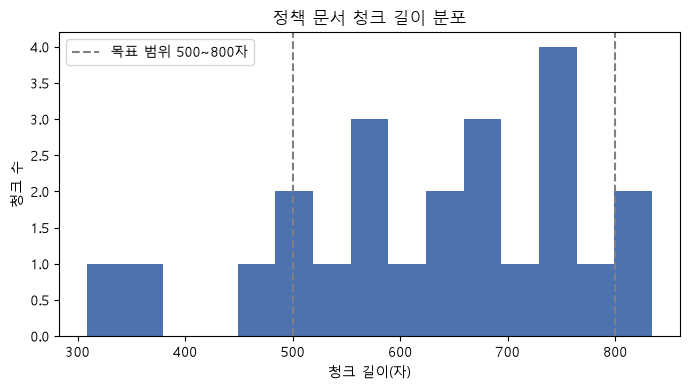

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lengths, bins=15, color="#4C72B0")
ax.axvline(CHUNK_MIN, color="gray", linestyle="--", label=f"목표 범위 {CHUNK_MIN}~{CHUNK_MAX}자")
ax.axvline(CHUNK_MAX, color="gray", linestyle="--")
ax.set_title("정책 문서 청크 길이 분포")
ax.set_xlabel("청크 길이(자)")
ax.set_ylabel("청크 수")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "01_chunk_length_distribution.png", dpi=150)
plt.show()

## 3. 모델링 — 청크 임베딩 (사전학습 모델, 검색 전용)

In [5]:
model = SentenceTransformer("intfloat/multilingual-e5-base")

passage_texts = [f"passage: {c['chunk_content']}" for c in all_chunks]
embeddings = model.encode(passage_texts, batch_size=32, show_progress_bar=True, normalize_embeddings=True)
for chunk, embedding in zip(all_chunks, embeddings):
    chunk["embedding"] = embedding
print("임베딩 완료:", embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

임베딩 완료: (23, 768)


## 4. 검색 품질 검증

지도학습 라벨이 없어, 실제 상담에서 나올 법한 질문으로 상위 검색 결과가 관련 있는 청크를 찾는지 확인한다.

In [6]:
def search_chunks(question: str, country_code: str, k: int = 3):
    query_embedding = model.encode(f"query: {question}", normalize_embeddings=True)
    subset = [c for c in all_chunks if c["country_code"] == country_code]
    sims = np.array([np.dot(c["embedding"], query_embedding) for c in subset])
    top_idx = np.argsort(-sims)[:k]
    return [(subset[i]["title"], subset[i]["chunk_content"][:80], float(sims[i])) for i in top_idx]


sample_questions = [
    ("CAN", "Express Entry 신청에 필요한 서류가 뭐야?"),
    ("AUS", "Subclass 189 비자는 스폰서가 필요해?"),
    ("GBR", "Skilled Worker 비자는 영어 능력 증명이 필요해?"),
]

for country, question in sample_questions:
    print("=" * 90)
    print(f"[{country}] {question}")
    for title, snippet, score in search_chunks(question, country):
        print(f"  ({score:.3f}) {title} — {snippet}...")

[CAN] Express Entry 신청에 필요한 서류가 뭐야?
  (0.814) Express Entry 전체 안내 — Express Entry

Express Entry is an online system that we use to manage immigrati...
  (0.802) Category-based Selection 기준 — Express Entry: Category-based selection

What is category-based selection

In ca...
  (0.790) Category-based Selection 기준 — To be eligible for an invitation through a category-based round, you must:
meet ...
[AUS] Subclass 189 비자는 스폰서가 필요해?
  (0.752) Skilled Independent Visa Subclass 189 전체 안내 — Skilled Independent visa (subclass 189)

This visa is for invited workers, eligi...
  (0.736) Skilled Independent Visa Subclass 189 전체 안내 — Processing Time: For an indication of processing times for this visa, use the vi...
  (0.711) Subclass 189 Points-tested Stream 서류·EOI·기술심사 안내 — Skilled Independent visa (subclass 189) — Points-tested stream

This visa lets i...
[GBR] Skilled Worker 비자는 영어 능력 증명이 필요해?


  (0.827) Skilled Worker Visa 전체 안내 — Skilled Worker visa: Overview

A Skilled Worker visa allows you to come to or st...
  (0.827) Skilled Worker 스폰서 지침 — Sponsor a Skilled Worker

Guidance for sponsors on sponsoring a Skilled Worker.
...
  (0.824) Skilled Worker Visa 필요 서류 — Skilled Worker visa: Documents you'll need to apply

When you apply you'll need ...


## 5. 학습(적용) — PostgreSQL에 적재

In [7]:
conn = psycopg2.connect(**DB_CONFIG)
register_vector(conn)
cur = conn.cursor()

cur.execute("SELECT country_code, visa_program_id FROM visa_programs")
visa_program_by_country = dict(cur.fetchall())
print("국가별 대표 비자 프로그램 ID:", visa_program_by_country)

# 재실행 시 중복 방지 (노트북은 언제든 다시 실행 가능해야 한다).
cur.execute("DELETE FROM policy_chunks")
cur.execute("DELETE FROM policy_documents")

document_id_by_key = {}
for doc in documents:
    content_hash = hashlib.sha256(doc["content"].encode("utf-8")).hexdigest()
    cur.execute(
        """
        INSERT INTO policy_documents (
            country_code, visa_program_id, document_title, document_type,
            source_url, verified_at, content_hash
        ) VALUES (%s, %s, %s, %s, %s, %s, %s)
        RETURNING document_id
        """,
        (
            doc["country_code"],
            visa_program_by_country.get(doc["country_code"]),
            doc["title"],
            "RAG_CONSULTATION",
            doc["source_url"],
            doc["verified_at"],
            content_hash,
        ),
    )
    document_id = cur.fetchone()[0]
    document_id_by_key[(doc["country_code"], doc["title"])] = document_id

chunk_rows = [
    (
        document_id_by_key[(c["country_code"], c["title"])],
        c["chunk_index"],
        c["title"],
        c["chunk_content"],
        len(c["chunk_content"]) // 4,  # 대략적인 토큰 수 추정치 (문자 수 / 4)
        c["embedding"].tolist(),
    )
    for c in all_chunks
]
psycopg2.extras.execute_batch(
    cur,
    """
    INSERT INTO policy_chunks (document_id, chunk_index, section_title, chunk_content, token_count, embedding)
    VALUES (%s, %s, %s, %s, %s, %s)
    """,
    chunk_rows,
    page_size=100,
)
conn.commit()

cur.execute("SELECT count(*) FROM policy_documents")
print("policy_documents 저장 수:", cur.fetchone()[0])
cur.execute("SELECT count(*) FROM policy_chunks")
print("policy_chunks 저장 수:", cur.fetchone()[0])
cur.close()
conn.close()

국가별 대표 비자 프로그램 ID: {'CAN': 1, 'AUS': 2, 'GBR': 3}
policy_documents 저장 수: 8
policy_chunks 저장 수: 23


## 결론

- 8개 공식 문서(캐나다 3, 호주 2, 영국 3)를 500~800자 청크로 분할해 `intfloat/multilingual-e5-base`로 임베딩하고
  `policy_documents`/`policy_chunks`(pgvector)에 저장했다.
- 실제 상담 질문 3건으로 검색 품질을 확인했고, 모두 관련 있는 청크가 상위에 검색됐다.
- 생성 모델은 아직 실 서비스(vLLM + Qwen3-8B-AWQ)가 없어 로컬 Ollama(`gemma2:latest`)로 대체해 개발·검증한다.
- 실험 결과 요약: `document_JinAhKwak/03_rag_chunks_results.md`.